# Data Exploration & Quality Checks

Generates synthetic **bank transaction training data** (categorization, fraud detection, spending insights, customer Q&A), validates it against the schema, and visualizes instruction/output length distributions before fine-tuning.

## Step 1: Generate Sample Data

Creates a synthetic bank transaction instruction dataset (1000 unique examples covering transaction categorization, fraud analysis, spending insights, and customer support Q&A) and splits it into train/eval/test.

In [ ]:
import sys
from pathlib import Path

RUNEBOOK_ROOT = Path.cwd()  # notebook 01's clone cell already chdir'd here
if str(RUNEBOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(RUNEBOOK_ROOT))

from scripts.prepare_data import create_sample_data, split_data, validate_and_report

raw_path = RUNEBOOK_ROOT / "data/RAW/training_data.jsonl"
if not raw_path.exists():
    create_sample_data(raw_path, num_samples=1000)
else:
    print(f"Using existing raw data: {raw_path}")

splits = split_data(raw_path)
print("\nData split into train/eval/test")

## Step 2: Validate Splits Against Schema

In [0]:
from src.data_loader import DataLoader

for split_name in ["train", "eval", "test"]:
    path = RUNEBOOK_ROOT / f"data/curated/{split_name}.jsonl"
    stats = DataLoader.validate_dataset(path)
    print(f"\n{split_name.upper()} ({path}):")
    for key, value in stats.items():
        print(f"  {key}: {value}")


TRAIN (data/curated/train.jsonl):
  total_examples: 240
  avg_instruction_length: 77.57916666666667
  max_instruction_length: 108
  avg_output_length: 442.79583333333335
  max_output_length: 1013

EVAL (data/curated/eval.jsonl):
  total_examples: 30
  avg_instruction_length: 79.36666666666666
  max_instruction_length: 108
  avg_output_length: 608.3
  max_output_length: 1013

TEST (data/curated/test.jsonl):
  total_examples: 30
  avg_instruction_length: 78.53333333333333
  max_instruction_length: 101
  avg_output_length: 324.53333333333336
  max_output_length: 628


## Step 3: Inspect Example Prompts

Show how a few examples are formatted as chat messages for fine-tuning.

In [0]:
train_examples = DataLoader.load_dataset(RUNEBOOK_ROOT / "data/curated/train.jsonl")

for example in train_examples[:3]:
    print("--- Chat messages ---")
    for msg in example.to_chat_messages():
        print(f"  [{msg['role']}] {msg['content']}")
    print()

--- Chat messages ---
  [user] Categorize the following bank transaction based on its description.
RAPPI*RAPPI COL - $45,000 COP - 2024-03-15 20:32
  [assistant] Category: Food & Delivery. This is a food delivery purchase through the Rappi platform.

--- Chat messages ---
  [user] Categorize the following bank transaction based on its description.
NETFLIX.COM - $38,900 COP - 2024-03-01 00:01
  [assistant] Category: Entertainment & Subscriptions. This is a recurring monthly subscription to Netflix streaming service.

--- Chat messages ---
  [user] Categorize the following bank transaction based on its description.
EXITO CALLE 80 - $187,500 COP - 2024-03-12 14:15
  [assistant] Category: Groceries & Supermarket. This is a purchase at Éxito supermarket, a major retail chain.



## Step 4: Length Distributions

Plot instruction and output length histograms across the training set.

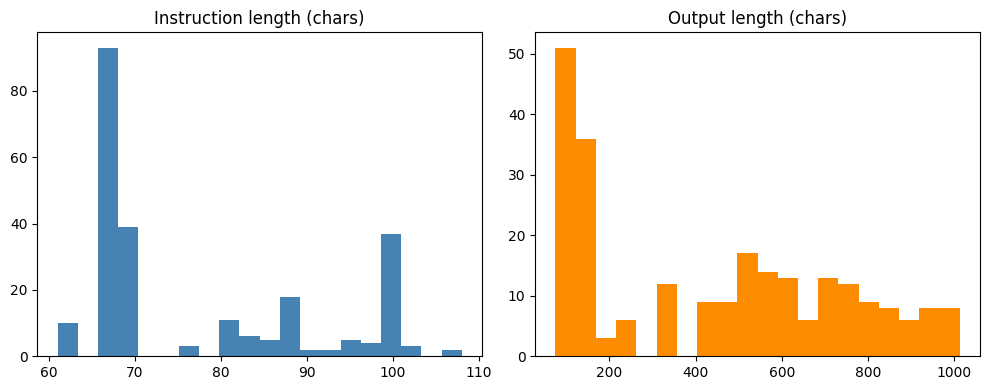

In [0]:
import matplotlib.pyplot as plt

instruction_lengths = [len(ex.instruction) for ex in train_examples]
output_lengths = [len(ex.output) for ex in train_examples]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(instruction_lengths, bins=20, color="steelblue")
axes[0].set_title("Instruction length (chars)")
axes[1].hist(output_lengths, bins=20, color="darkorange")
axes[1].set_title("Output length (chars)")
plt.tight_layout()
plt.show()

## Step 5: Task Type Distribution

Bucket examples by their instruction text as a rough proxy for task type.

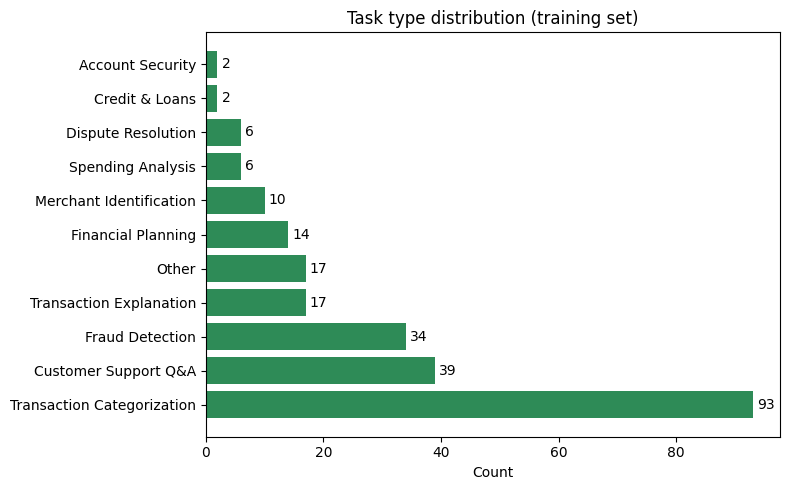

In [0]:
from collections import Counter

def classify_task(instruction: str) -> str:
    i = instruction.lower()
    if "categorize" in i:
        return "Transaction Categorization"
    elif "fraud" in i:
        return "Fraud Detection"
    elif "spending insight" in i or "monthly transaction summary" in i:
        return "Spending Analysis"
    elif "customer question" in i:
        return "Customer Support Q&A"
    elif "pending transaction" in i or "explain" in i:
        return "Transaction Explanation"
    elif "dispute" in i or "disputing" in i:
        return "Dispute Resolution"
    elif "merchant" in i or "recognize" in i:
        return "Merchant Identification"
    elif "savings" in i or "budget" in i or "financial" in i:
        return "Financial Planning"
    elif "declined" in i or "payment" in i:
        return "Payment Failures"
    elif "security" in i:
        return "Account Security"
    elif "credit" in i:
        return "Credit & Loans"
    elif "tax" in i:
        return "Tax Analysis"
    elif "international" in i or "fees" in i:
        return "International Transactions"
    else:
        return "Other"

task_counts = Counter(classify_task(ex.instruction) for ex in train_examples)
task_counts = dict(task_counts.most_common())

plt.figure(figsize=(8, 5))
bars = plt.barh(list(task_counts.keys()), list(task_counts.values()), color="seagreen")
plt.xlabel("Count")
plt.title("Task type distribution (training set)")
plt.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

## Data Exploration Complete

Data is validated and ready for fine-tuning. Next: run `03_finetuning.ipynb`.